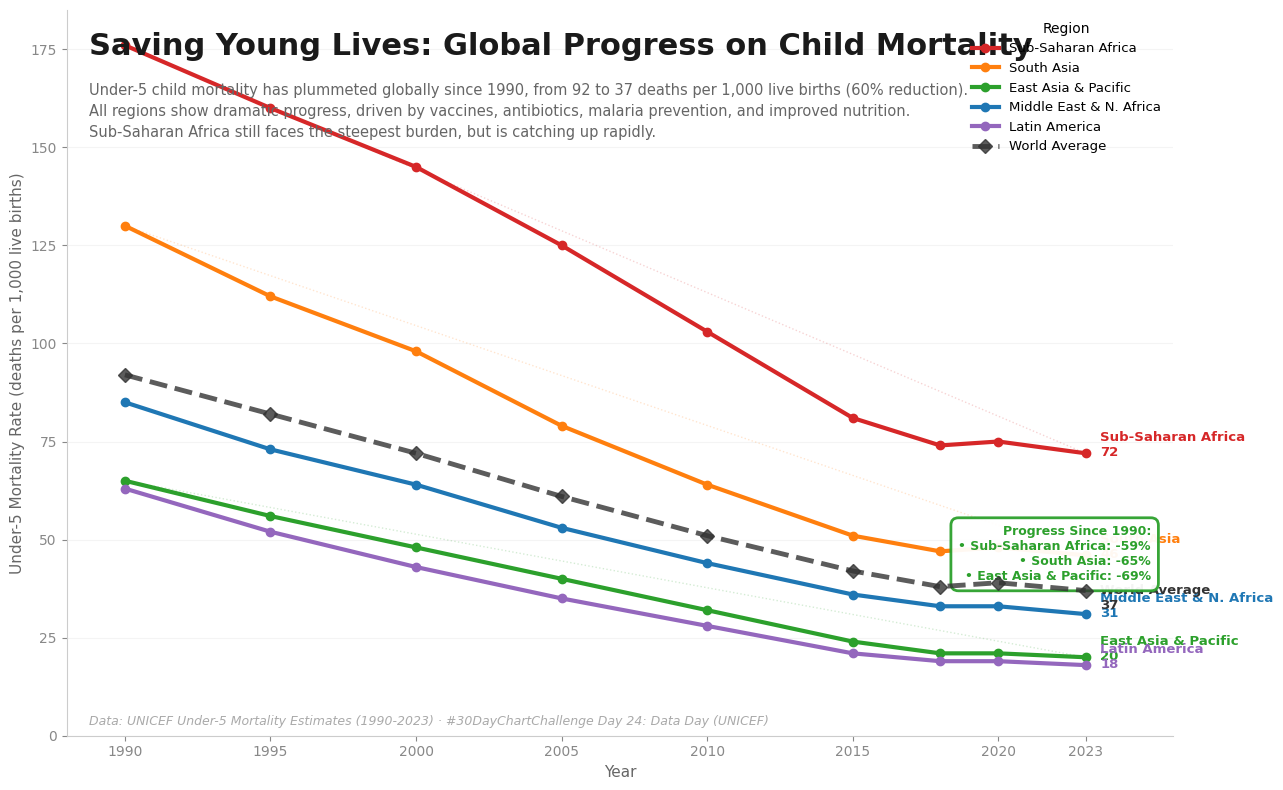

In [1]:
"""
#30DayChartChallenge — Day 24: Data Day (UNICEF)
"Saving Young Lives: Child Mortality Decline Worldwide" — timeseries progress on children's health
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Under-5 child mortality rate by region (deaths per 1,000 live births) - UNICEF data
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Under-5 child mortality rate over time
# ---------------------------------------------------------------------------
data = {
    "Year": [1990, 1995, 2000, 2005, 2010, 2015, 2018, 2020, 2023],
    "Sub_Saharan_Africa": [176, 160, 145, 125, 103, 81, 74, 75, 72],
    "South_Asia": [130, 112, 98, 79, 64, 51, 47, 48, 46],
    "East_Asia_Pacific": [65, 56, 48, 40, 32, 24, 21, 21, 20],
    "Middle_East_North_Africa": [85, 73, 64, 53, 44, 36, 33, 33, 31],
    "Latin_America": [63, 52, 43, 35, 28, 21, 19, 19, 18],
    "World": [92, 82, 72, 61, 51, 42, 38, 39, 37]
}

df = pd.DataFrame(data)

# ---------------------------------------------------------------------------
# 2. PLOT
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(13, 8), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Color palette for regions
colors = {
    "Sub_Saharan_Africa": "#d62728",
    "South_Asia": "#ff7f0e",
    "East_Asia_Pacific": "#2ca02c",
    "Middle_East_North_Africa": "#1f77b4",
    "Latin_America": "#9467bd",
    "World": "#333333"
}

region_labels = {
    "Sub_Saharan_Africa": "Sub-Saharan Africa",
    "South_Asia": "South Asia",
    "East_Asia_Pacific": "East Asia & Pacific",
    "Middle_East_North_Africa": "Middle East & N. Africa",
    "Latin_America": "Latin America",
    "World": "World Average"
}

# Plot lines for each region
for region in ["Sub_Saharan_Africa", "South_Asia", "East_Asia_Pacific", 
               "Middle_East_North_Africa", "Latin_America"]:
    ax.plot(df["Year"], df[region], color=colors[region], linewidth=3, marker="o",
            markersize=6, label=region_labels[region], zorder=3)

# Plot world average as bold dashed line
ax.plot(df["Year"], df["World"], color=colors["World"], linewidth=3.5, marker="D",
        markersize=7, linestyle="--", label=region_labels["World"], zorder=4, alpha=0.8)

# Direct labels at end of lines
end_year = df["Year"].iloc[-1]
for region in ["Sub_Saharan_Africa", "South_Asia", "East_Asia_Pacific", 
               "Middle_East_North_Africa", "Latin_America", "World"]:
    last_value = df[region].iloc[-1]
    offset = 2 if region != "World" else -2
    ax.text(end_year + 0.5, last_value + offset, f"{region_labels[region]}\n{last_value:.0f}",
            fontsize=9.5, fontweight="600", color=colors[region], va="center")

# Highlight progress: compare 1990 vs 2023
for region in ["Sub_Saharan_Africa", "South_Asia", "East_Asia_Pacific"]:
    start_val = df[region].iloc[0]
    end_val = df[region].iloc[-1]
    reduction = ((start_val - end_val) / start_val) * 100
    
    # Connect start and end with subtle line showing progress
    ax.plot([df["Year"].iloc[0], df["Year"].iloc[-1]], [start_val, end_val],
            color=colors[region], linewidth=1, alpha=0.2, linestyle=":", zorder=1)

# Minimal styling
ax.set_xlim(1988, 2026)
ax.set_ylim(0, 185)
ax.spines[["top", "right"]].set_visible(False)
ax.spines[["left", "bottom"]].set_color("#cccccc")
ax.grid(True, color="#eeeeee", linewidth=0.8, alpha=0.6, axis="y", zorder=0)
ax.set_axisbelow(True)

ax.set_xlabel("Year", fontsize=11, color="#666666", fontweight="500")
ax.set_ylabel("Under-5 Mortality Rate (deaths per 1,000 live births)", fontsize=11, color="#666666", fontweight="500")
ax.set_xticks([1990, 1995, 2000, 2005, 2010, 2015, 2020, 2023])
ax.tick_params(colors="#888888", labelsize=10)

# Legend
ax.legend(loc="upper right", fontsize=9.5, frameon=False, title="Region", title_fontsize=10)

# Title & subtitle
ax.text(0.02, 0.97, "Saving Young Lives: Global Progress on Child Mortality",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.90,
        "Under-5 child mortality has plummeted globally since 1990, from 92 to 37 deaths per 1,000 live births (60% reduction).\n"
        "All regions show dramatic progress, driven by vaccines, antibiotics, malaria prevention, and improved nutrition.\n"
        "Sub-Saharan Africa still faces the steepest burden, but is catching up rapidly.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Key achievement box
achievements = "Progress Since 1990:\n"
achievements += "• Sub-Saharan Africa: -59%\n"
achievements += "• South Asia: -65%\n"
achievements += "• East Asia & Pacific: -69%"

ax.text(0.98, 0.25, achievements,
        fontsize=9, color="#2ca02c", fontweight="bold", transform=ax.transAxes, 
        ha="right", va="center",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#fff", edgecolor="#2ca02c", linewidth=2, alpha=0.95))

# Source
ax.text(0.02, 0.01,
        "Data: UNICEF Under-5 Mortality Estimates (1990-2023) · #30DayChartChallenge Day 24: Data Day (UNICEF)",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day24_unicef.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()